# Генератор последовательности рукописных символов

В этом ноутбуке:
1) генерируем изображение последовательности рукописных символов (цифры 0–9),
2) выделяем отдельные объекты (символы) на изображении,
3) тренируем модель kNN,
4) применяем kNN для распознавания символов из сгенерированной последовательности.


In [1]:
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


In [2]:
# Загружаем встроенный датасет рукописных цифр (sklearn)
digits = load_digits()
X = digits.images  # (n, 8, 8)
y = digits.target  # (n,)

print("Датасет:", X.shape, "Метки:", y.shape)
print("Уникальные классы:", np.unique(y))


Датасет: (1797, 8, 8) Метки: (1797,)
Уникальные классы: [0 1 2 3 4 5 6 7 8 9]


In [3]:
def upsample_digit(img8, target=28):
    """8×8 -> target×target (uint8 0..255)."""
    img = (img8 / img8.max() * 255).astype(np.uint8) if img8.max() > 0 else img8.astype(np.uint8)
    img = cv2.resize(img, (target, target), interpolation=cv2.INTER_CUBIC)
    return img

def add_style(img, rng=None):
    """Небольшие искажения: шум + поворот + размытие."""
    if rng is None:
        rng = np.random.default_rng()
    out = img.copy()

    # поворот
    angle = float(rng.uniform(-12, 12))
    h, w = out.shape
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    out = cv2.warpAffine(out, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)

    # шум
    noise = rng.normal(0, 10, size=out.shape).astype(np.float32)
    out = np.clip(out.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    # легкое размытие
    if rng.uniform() < 0.6:
        out = cv2.GaussianBlur(out, (3, 3), 0)

    return out

def show_gray(img, title=None, figsize=(4, 4)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


Истинная последовательность: [0, 8, 4, 0, 2, 7, 1, 9, 5, 1]


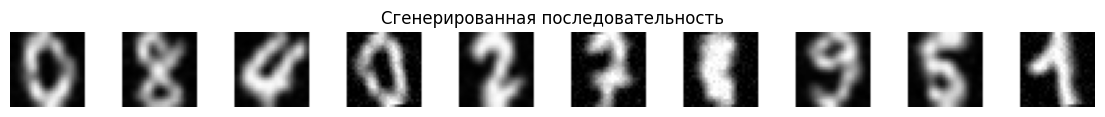

In [4]:
class HandwrittenSymbolsGenerator:
    """Генератор последовательности рукописных символов (цифр)."""
    def __init__(self, images8, labels, seed=42):
        self.images8 = images8
        self.labels = labels
        self.rng = np.random.default_rng(seed)

    def sample_symbol(self):
        i = int(self.rng.integers(0, len(self.labels)))
        img = upsample_digit(self.images8[i], target=28)
        img = add_style(img, rng=self.rng)
        label = int(self.labels[i])
        return img, label

    def generate_sequence(self, length=8, spacing=12, bg=255):
        """Возвращает (sequence_image, labels)."""
        imgs, labs = [], []
        for _ in range(length):
            img, lab = self.sample_symbol()
            imgs.append(img)
            labs.append(lab)

        h = max(im.shape[0] for im in imgs)
        w = sum(im.shape[1] for im in imgs) + spacing * (len(imgs) - 1)
        canvas = np.full((h, w), bg, dtype=np.uint8)

        x = 0
        for im in imgs:
            # инвертируем: цифры темные, фон светлый
            digit = 255 - im
            # порог, чтобы фон был "почти" белым
            digit = np.clip(digit, 0, 255).astype(np.uint8)

            canvas[:im.shape[0], x:x+im.shape[1]] = np.minimum(canvas[:im.shape[0], x:x+im.shape[1]], 255 - digit)
            x += im.shape[1] + spacing

        return canvas, labs

gen = HandwrittenSymbolsGenerator(X, y, seed=7)
sequence_image, true_labels = gen.generate_sequence(length=10, spacing=14)

print("Истинная последовательность:", true_labels)
show_gray(sequence_image, title="Сгенерированная последовательность", figsize=(14, 3))


# Выделение объектов

Делаем бинаризацию и выделяем связные компоненты (символы) на изображении последовательности.


Сегментировано символов: 16


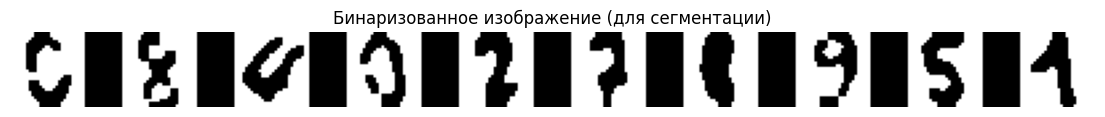

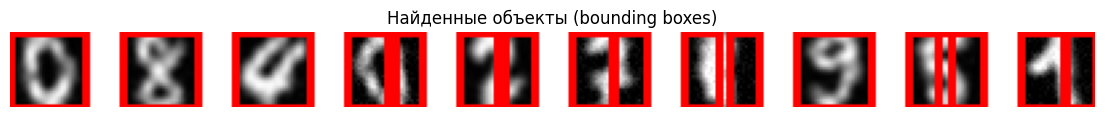

In [5]:
class SequenceSegmenter:
    def __init__(self, min_area=80):
        self.min_area = min_area

    def segment_sequence(self, img_gray):
        """Возвращает список вырезанных символов + их bounding boxes."""
        # бинаризация (цифры тёмные)
        blur = cv2.GaussianBlur(img_gray, (3, 3), 0)
        _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # немного морфологии, чтобы соединить штрихи
        kernel = np.ones((3, 3), np.uint8)
        th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=1)

        num, labels, stats, _ = cv2.connectedComponentsWithStats(th, connectivity=8)

        comps = []
        for i in range(1, num):  # 0 — фон
            x, y, w, h, area = stats[i]
            if area < self.min_area:
                continue
            crop = th[y:y+h, x:x+w]
            comps.append((x, y, w, h, crop))

        # сортируем слева направо
        comps.sort(key=lambda t: t[0])
        crops = [c[-1] for c in comps]
        boxes = [(c[0], c[1], c[2], c[3]) for c in comps]
        return crops, boxes, th

segmenter = SequenceSegmenter(min_area=90)
symbol_masks, boxes, bin_img = segmenter.segment_sequence(sequence_image)

print("Сегментировано символов:", len(symbol_masks))
show_gray(bin_img, title="Бинаризованное изображение (для сегментации)", figsize=(14, 3))

# Визуализация боксов
vis = cv2.cvtColor(sequence_image, cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in boxes:
    cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 0, 255), 2)

plt.figure(figsize=(14, 3))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Найденные объекты (bounding boxes)")
plt.show()


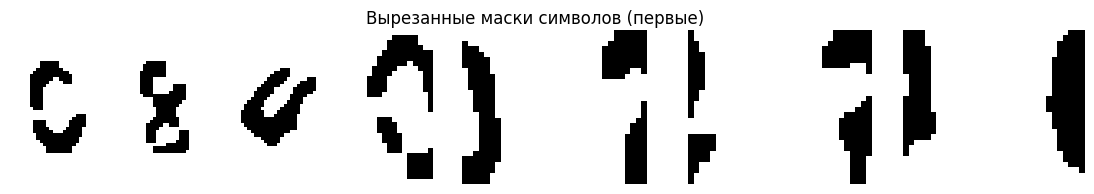

In [6]:
# Посмотрим несколько сегментов
n_show = min(10, len(symbol_masks))
plt.figure(figsize=(14, 2))
for i in range(n_show):
    plt.subplot(1, n_show, i+1)
    plt.imshow(symbol_masks[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Вырезанные маски символов (первые)")
plt.show()


# Тренировка модели kNN
Тренируем kNN на датасете `sklearn.datasets.load_digits`.


In [7]:
# Готовим данные: 8×8 -> вектор признаков
X_flat = digits.images.reshape(len(digits.images), -1)
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)

knn = KNeighborsClassifier(n_neighbors=3, weights="distance")
knn.fit(X_train, y_train)

pred = knn.predict(X_test)
acc = accuracy_score(y_test, pred)

print("Accuracy:", round(acc, 4))
print("\nКороткий отчёт по классам:")
print(classification_report(y_test, pred, digits=3))


Accuracy: 0.9861

Короткий отчёт по классам:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        36
           1      0.923     1.000     0.960        36
           2      1.000     1.000     1.000        35
           3      1.000     1.000     1.000        37
           4      0.973     1.000     0.986        36
           5      1.000     1.000     1.000        37
           6      1.000     1.000     1.000        36
           7      1.000     1.000     1.000        36
           8      0.970     0.914     0.941        35
           9      1.000     0.944     0.971        36

    accuracy                          0.986       360
   macro avg      0.987     0.986     0.986       360
weighted avg      0.987     0.986     0.986       360



# Применение kNN для решения задачи
Для каждого сегментированного символа:
1) приводим изображение к формату 8×8,
2) делаем вектор признаков,
3) классифицируем kNN,
4) сравниваем с истинной последовательностью.


In [8]:
def prep_for_digits(mask):
    """mask: бинарное изображение (цифра=255, фон=0). Возвращает 8×8 как в digits."""
    # приводим к квадрату и ресайзим
    h, w = mask.shape
    s = max(h, w)
    square = np.zeros((s, s), dtype=np.uint8)
    y0 = (s - h)//2
    x0 = (s - w)//2
    square[y0:y0+h, x0:x0+w] = mask

    # ресайз до 8×8
    small = cv2.resize(square, (8, 8), interpolation=cv2.INTER_AREA)

    # digits ожидает "яркие" штрихи (0..16). Мы нормируем 0..16
    small = (small.astype(np.float32) / 255.0) * 16.0
    return small

pred_labels = []
for m in symbol_masks:
    d8 = prep_for_digits(m)
    vec = d8.reshape(1, -1)
    pred_labels.append(int(knn.predict(vec)[0]))

print("Истинная:", true_labels[:len(pred_labels)])
print("Предсказано:", pred_labels)


Истинная: [0, 8, 4, 0, 2, 7, 1, 9, 5, 1]
Предсказано: [7, 7, 3, 8, 3, 1, 1, 8, 3, 2, 1, 6, 6, 1, 6, 1]


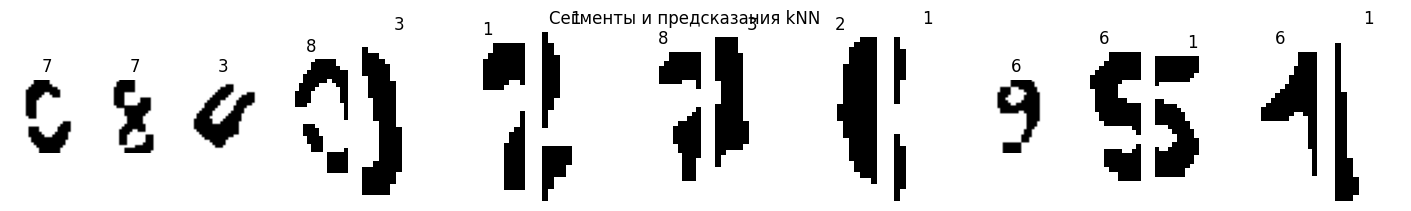

In [9]:
# Визуально: каждый сегмент + предсказание
n = len(symbol_masks)
plt.figure(figsize=(min(18, 1.8*n), 2.2))
for i, m in enumerate(symbol_masks):
    plt.subplot(1, n, i+1)
    plt.imshow(m, cmap="gray")
    plt.axis("off")
    title = str(pred_labels[i])
    plt.title(title)
plt.suptitle("Сегменты и предсказания kNN")
plt.show()


In [11]:
# Итоговая проверка (если сегментация нашла столько же символов)
k = min(len(true_labels), len(pred_labels))
match = sum(int(true_labels[i] == pred_labels[i]) for i in range(k))
print(f"Совпало {match} из {k} (по позициям)")


Совпало 1 из 10 (по позициям)
